# Problem Background: The Great Migration

**Year: 3050**

The world as we knew it has changed drastically. After decades of conflict, disease, and a relentless zombie apocalypse, the human race faces extinction. The relentless hordes of the undead have ravaged cities, reduced populations, and devastated the planet's ecosystems.

In a desperate bid for survival, the remaining factions of humanity have united to embark on a monumental journey to a new home: **Earth Junior**, a distant planet believed to be free from the scourge of the undead.

As they prepare for this monumental journey, the survival of the human race hinges on their ability to screen potential passengers at the spaceship station. It is crucial that no zombies are allowed to enter the spacecraft, as even a single infected individual could jeopardize the entire mission and the future of humanity.

In this dire situation, you find yourself as the last surviving machine learning engineer, tasked with developing a screening model to predict the zombie-ness of a person. A high human-zombie score would mean the person is likely to be a zombie. The fate of the human race depends on your expertise in machine learning, and you must create a reliable system to ensure the success of this migration to 'Earth Junior'.


# Task 1 -- Linear Regression  

### Introduction

In this assignment, you will be implementing Linear Regression and Logistic Regression models for the provided dataset from scratch, and will be familiarizing yourself with the corresponding scikit-learn APIs. A description of the problem statement is given at the start of each part.

After this notebook you should be able to:

- Set up simple regression tasks.

- Understand the working of Linear Regression models and simple data preprocessing.

- Implement Linear Regression models using simple `numpy`.

Have fun!



# Human-Zombie Dataset

This dataset simulates human and zombie characteristics based on various lifestyle and physical traits. The dataset contains 1,000 entries, each with features that correlate with a continuous "Human-Zombie Score" ranging from 0 (complete human) to 100 (complete zombie).

This generation of human race has smart-chips embedded in their bloodstream that can keep track of and record all these features.

## Features

- **Height (cm):** The height of the individual measured in centimeters, it decreases with zombie score because zombies are known to shrink in height.

- **Weight (kg):** The weight of the individual measured in kilograms. Zombies tend to have a lower weight because of loss of muscle mass, tissue, organs (and soul??).

- **Screen Time (hrs):** The average number of hours spent in front of screens daily. This feature increases with the human-zombie score, reflecting a more sedentary lifestyle.

- **Junk Food (days/week):** The average number of days per week the individual consumes junk food. This feature also increases with the human-zombie score, indicating poorer dietary habits.

- **Physical Activity (hrs/week):** The total hours spent on physical activities per week. This feature decreases as the human-zombie score increases, suggesting a decline in physical activity.

- **Task Completion (scale):** Scale from 0 to 10 representing how often tasks are completed on time (0 = always on time, 10 = never on time). This score decreases with a higher human-zombie score, indicating declining productivity.

- **Human-Zombie Score:** A continuous score from 0 to 100 representing the degree of "zombie-ness" of the individual, where 0 is fully human and 100 is completely zombie-like.

## Usage

This dataset can be used for various analyses, including regression modeling to predict the human-zombie score based on lifestyle and physical traits.


## Multivariate Linear Regression

In this part, you will implement multivariate linear regression (from scratch) to predict the the human-zombie score during screening before the person can be allowed to enter the spaceship.

To do this, you have the human-zombie-datset.csv containing 1000 examples of the features described above and their scores.

Each one of these input features is stored using a different scale. The features include ranges 0-10, 17-100 and some between 130-200.  This is often the case with real-world data, and understanding how to explore and clean such data is an important skill to develop.

A common way to normalize features that use different scales and ranges is:

- Subtract the mean value of each feature from the dataset.

- After subtracting the mean, additionally scale (divide) the feature values by their respective standard deviations.

Note: We only use examples of the train set to estimate the mean and standard deviation.

You have to follow exactly the same steps as above i.e. implement hypothesis, cost function and gradient descent for multivariate linear regression to learn parameters $\theta$ using train set. Finally, report the cost (error) using your learned parameters $\theta$ on test set.








### What is Linear Regression?

Linear regression is a fundamental machine learning algorithm that models the relationship between a dependent variable (target) and one or more independent variables (features) using a linear equation.

**The Linear Regression Equation:**

For multivariate linear regression (multiple features), the hypothesis function is:

$$h_\theta(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + ... + \theta_n x_n$$

Or in matrix form:
$$h_\theta(x) = \theta^T x$$

Where:
- $h_\theta(x)$ = predicted value (Human-Zombie Score in our case)
- $\theta_0$ = bias term (intercept)
- $\theta_1, \theta_2, ..., \theta_n$ = weights/parameters for each feature
- $x_1, x_2, ..., x_n$ = input features (Height, Weight, Screen Time, etc.)

### What Do We Actually Find in Linear Regression?

Linear regression aims to find the **optimal parameters** $\theta$ that best fit our data. These parameters represent:

1. **$\theta_0$ (Bias)**: The baseline Human-Zombie Score when all features are zero
2. **$\theta_1$ (Height coefficient)**: How much the score changes per cm of height
3. **$\theta_2$ (Weight coefficient)**: How much the score changes per kg of weight
4. **And so on for each feature...**

The goal is to find the $\theta$ values that minimize the difference between our predictions and actual Human-Zombie Scores!

---

## Cost Functions: Measuring Our Mistakes

A cost function measures how wrong our predictions are. Different cost functions have different properties and use cases.

### 1. Mean Squared Error (MSE) - Most Common
$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2$$

**Properties:**
- Penalizes large errors heavily (squared term)
- Differentiable everywhere (good for gradient descent)
- Sensitive to outliers

### 2. Mean Absolute Error (MAE) - Robust to Outliers
$$J(\theta) = \frac{1}{m} \sum_{i=1}^{m} |h_\theta(x^{(i)}) - y^{(i)}|$$

**Properties:**
- Linear penalty for errors
- More robust to outliers than MSE
- Not differentiable at zero (can cause issues in optimization)

### 3. Root Mean Squared Error (RMSE) - Interpretable Scale
$$J(\theta) = \sqrt{\frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2}$$

**Properties:**
- Same scale as the target variable
- Easy to interpret (error in same units as Human-Zombie Score)
- Still sensitive to outliers like MSE

### When to Use Which Cost Function?

- **MSE**: Default choice, works well when you want to penalize large errors
- **MAE**: When your data has outliers or you want equal penalty for all errors
- **RMSE**: When you want interpretable error metrics in the same scale as your target

---

### Part A: Implementation from Scratch

#### Imports

Start off with importing in the required libraries. Note that you are **only** allowed to use `sklearn`'s train_test_split in this part and no other function from `sklearn`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

#### Preparing Data

Load in your dataset and perform train-test split. Apply preprocessing steps to cater to missing values, categorical variables etc. if necessary.

In [2]:
# Load dataset and print first few rows
df = pd.read_csv('human_zombie_dataset_v5.csv')
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nFirst 5 rows:")
df.head()


Shape: (1000, 7)

Missing values:
Height (cm)                     0
Weight (kg)                     0
Screen Time (hrs)               0
Junk Food (days/week)           0
Physical Activity (hrs/week)    0
Task Completion (scale)         0
Human-Zombie Score              0
dtype: int64

First 5 rows:


,Height (cm),Weight (kg),Screen Time (hrs),Junk Food (days/week),Physical Activity (hrs/week),Task Completion (scale),Human-Zombie Score
0,157,41,8.455099,5.622736,4.474819,6.166119,54.881350
1,151,40,8.581430,5.922744,3.749707,1.084877,71.518937
2,166,45,5.018847,5.746557,4.596662,2.030814,60.276338
3,160,75,6.417010,4.634547,4.546153,3.360430,54.488318
4,153,74,4.417465,4.740153,6.601801,5.758603,42.365480


In [3]:
# Define features and target
feature_cols = [
    'Height (cm)', 'Weight (kg)', 'Screen Time (hrs)',
    'Junk Food (days/week)', 'Physical Activity (hrs/week)',
    'Task Completion (scale)'
]
target_col = 'Human-Zombie Score'

X = df[feature_cols].values
y = df[target_col].values

# Train-test split  (only sklearn allowed here)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test  shape:", y_test.shape)


X_train shape: (800, 6)
X_test  shape: (200, 6)
y_train shape: (800,)
y_test  shape: (200,)


#### Normalizing Data  

For models like Linear/Logistic Regression, and even for Neural Networks, Standardization/Normalization is a non-negotiable step in the preprocessing stage. You would find your model **broken** if you do not normalize your data.

One nice way to implement this is to create a class, `StandardScaler` that can be used to store the mean and standard deviation of each feature of the training set. The `StandardScaler` class also has two functions, `fit` and `transform`.

- The `fit` function is used to calculate the mean and standard deviation of each feature of the training set.

- The `transform` function is used to transform all the features using the corresponding mean and standard deviation, i.e. subtracting the mean and dividing by the standard deviation.

A very subtle and important point to note here is that the mean and standard deviation should be calculated only on the training set, and then applied to the test set. This is because in real-world scenarios, we do not have access to the test set, and hence we cannot calculate the mean and standard deviation of the test set.

In [4]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()
#fit transformation; this computes the mean and std on training data and scales it. Convenient shortcut for Training data.
X_train_scaled = scaler.fit_transform(X_train)

# Fit on training data and transform it. 
# Apply the SAME transformation to test data (no re-fitting!)
X_test_scaled = scaler.transform(X_test)

print("Mean  (per feature):", np.round(scaler.mean_, 4))
print("Scale (per feature):", np.round(scaler.scale_, 4))
print("\nX_train_scaled sample (first row):", X_train_scaled[0])


Mean  (per feature): [155.6575  58.1088   6.4905   4.4493   5.0542   4.9927]
Scale (per feature): [12.5845 15.0428  2.4966  1.5208  2.9641  2.9777]

X_train_scaled sample (first row): [-0.84687364 -0.40609255 -0.12331522 -0.51572628  0.15034095  0.3438235 ]


## Gradient Descent: The Mathematical Journey to Minimum

### What is Gradient Descent?

Imagine you're a zombie trying to find the lowest point in a valley (minimum cost) while blindfolded. Gradient descent is like feeling the slope of the ground and taking steps in the steepest downhill direction!

### The Mathematics Behind Gradient Descent

**The Gradient**: The gradient $\nabla J(\theta)$ tells us the direction of steepest increase in our cost function.

For MSE cost function, the gradient with respect to each parameter is:

$$\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)}) x_j^{(i)}$$

**The Update Rule**: We move in the opposite direction of the gradient:

$$\theta_j := \theta_j - \alpha \frac{\partial J(\theta)}{\partial \theta_j}$$

Where:
- $\alpha$ = learning rate (how big steps we take)
- $\frac{\partial J(\theta)}{\partial \theta_j}$ = partial derivative (slope) of cost function

### How We Calculate Gradients Step by Step:

1. **Forward Pass**: Calculate predictions using current $\theta$
2. **Calculate Error**: Find difference between predictions and actual values
3. **Calculate Gradients**: Use the error to compute how much to change each $\theta$
4. **Update Parameters**: Move $\theta$ in the direction that reduces cost
5. **Repeat**: Until convergence or maximum iterations


#### Gradient Descent Implementation




Now that your data is ready, you can start implementing the gradient descent algorithm.

You should be creating a class `LinearRegression`. This means implementing the following methods:

- `__init__`: The constructor of the class. You can initialize any variables, like the learning rate and the number of iterations, here.

- `fit`: This method will be used to train your model. It should take in the training data and labels as parameters, and learn the parameters using gradient descent. Save the loss values after every iteration in a list, and return it (for plotting later).

- `predict`: This method will be used to predict the labels for a given set of test data. It should take in the test data as a parameter, and return the predicted labels.

- `score`: This method will be used to calculate the mean square error for the test data. It should take in the test data and labels as parameters, and return the mean square error. Note that this is a unique case where the loss function and the final reported metric are the same.




1. Implement the `LinearRegression` class with support for different cost functions
2. Add methods for MSE, MAE, and RMSE
3. Compare how different cost functions affect the learning process
4. Visualize the gradient descent path

Training with MSE cost function
  Iter     0  |  Cost (mse) = 1656.516688  |  bias = 4.9537
  Iter   100  |  Cost (mse) = 13.340992  |  bias = 49.5353
  Iter   200  |  Cost (mse) = 13.316077  |  bias = 49.5365
  Iter   300  |  Cost (mse) = 13.314266  |  bias = 49.5365
  Iter   400  |  Cost (mse) = 13.314007  |  bias = 49.5365
  Iter   500  |  Cost (mse) = 13.313969  |  bias = 49.5365
  Iter   600  |  Cost (mse) = 13.313963  |  bias = 49.5365
  Iter   700  |  Cost (mse) = 13.313962  |  bias = 49.5365
  Iter   800  |  Cost (mse) = 13.313962  |  bias = 49.5365
  Iter   900  |  Cost (mse) = 13.313962  |  bias = 49.5365

Final parameters:
  bias (b / θ₀) = 49.5365
  θ1 (Height (cm)           ) = -1.3349
  θ2 (Weight (kg)           ) = -0.3092
  θ3 (Screen Time (hrs)     ) = 2.5121
  θ4 (Junk Food (days/week) ) = 7.9334
  θ5 (Physical Activity (hrs) = -9.8365
  θ6 (Task Completion (scale) = -8.9533

Train MSE : 26.6279
Test  MSE : 24.1441
Test  R²  : 0.9693


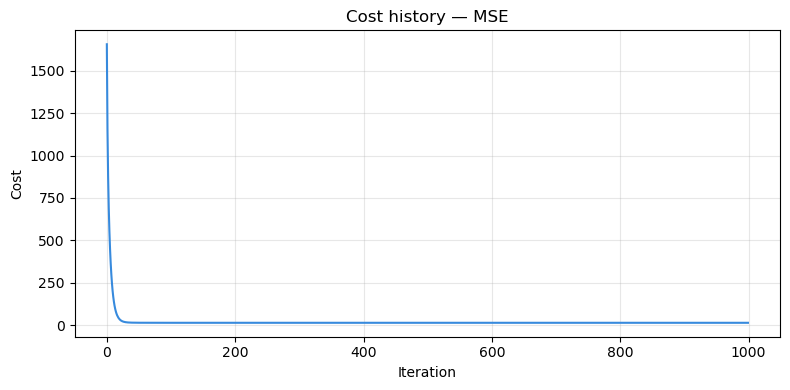

In [5]:
import numpy as np
import matplotlib.pyplot as plt


class LinearRegression:
    def __init__(self, learning_rate=0.01, num_iterations=1000, cost_function='mse'):
        """
        Initialize Linear Regression.

        Parameters:
        - learning_rate  : step size α for gradient descent
        - num_iterations : number of gradient descent iterations
        - cost_function  : 'mse', 'mae', or 'rmse'
        """
        self.learning_rate  = learning_rate #how fast model learns
        self.num_iterations = num_iterations #how many times we train
        self.cost_function  = cost_function #how we measure error
        self.cost_history   = []            #track error over time
        self.theta          = None   # includes bias as theta[0]
        self.theta_history  = []     # for gradient descent path plot
#Model created
    # ────────────────────────────────────────────────────────────────
    # PRIVATE HELPERS
    # ────────────────────────────────────────────────────────────────
#We add a column of 1s to input data, We add a column of 1s to input data
    def _add_bias(self, X):
        """Prepend a column of ones to X so theta[0] acts as bias b."""
        m = X.shape[0]
        return np.hstack([np.ones((m, 1)), X])   # shape (m, n+1)

    def _compute_cost(self, predictions, y):  #We calculate how wrong the model is Using Mean Squared Error (MSE)
        """                                   #👉 High cost = bad model 👉 Low cost = good model
        Compute cost based on selected cost function.
        Whiteboard formula (MSE):  J(θ) = 1/(2m) * Σ (h(xⁱ) - yⁱ)²
        """
        m      = len(y)
        errors = predictions - y

        if self.cost_function == 'mse':
            return (1 / (2 * m)) * np.sum(errors ** 2)
        elif self.cost_function == 'mae':
            return (1 / m) * np.sum(np.abs(errors))
        elif self.cost_function == 'rmse':
            return np.sqrt((1 / m) * np.sum(errors ** 2))
        else:
            raise ValueError(f"Unknown cost function: {self.cost_function}")

    def _compute_gradients(self, X, predictions, y):  #Which direction to move to reduce error
        """
        Compute gradients for gradient descent.

        Whiteboard formulas:
            ∂J/∂b  = (1/m) * Σ (h(xⁱ) - yⁱ)           ← bias  (no xⱼ)
            ∂J/∂θⱼ = (1/m) * Σ (h(xⁱ) - yⁱ) * xⱼⁱ     ← weights

        Since bias is stored as theta[0] with X[:,0]=1:
            X.T @ errors gives [Σerrors, Σerrors*x1, Σerrors*x2, ...]
        One line covers bias + all weights.
        """
        m      = len(y)
        errors = predictions - y

        if self.cost_function == 'mse' or self.cost_function == 'rmse':
            gradients = (1 / m) * (X.T @ errors)
        elif self.cost_function == 'mae':
            gradients = (1 / m) * (X.T @ np.sign(errors))
        else:
            raise ValueError(f"Unknown cost function: {self.cost_function}")

        return gradients   # shape (n+1,)

    # ────────────────────────────────────────────────────────────────
    # PUBLIC API
    # ────────────────────────────────────────────────────────────────

    def fit(self, X, y, verbose=True):
        """
        Train model using gradient descent.

        Returns cost_history list (for plotting).
        """
        X = np.array(X)
        y = np.array(y)

        X_b = self._add_bias(X)          # (m, n+1) — first col = 1 (bias)
        m, n_plus_1 = X_b.shape

        # Initialise all parameters (bias + weights) to zero
        self.theta = np.zeros(n_plus_1)
        self.cost_history  = []
        self.theta_history = []

        for i in range(self.num_iterations):
            predictions = X_b @ self.theta          # h(x) = Xθ
            cost        = self._compute_cost(predictions, y)
            gradients   = self._compute_gradients(X_b, predictions, y)

            # ── Simultaneous update (whiteboard rule) ──────────────
            # b  ← b  - α * ∂J/∂b
            # θⱼ ← θⱼ - α * ∂J/∂θⱼ   (all j at once)
            self.theta = self.theta - self.learning_rate * gradients

            self.cost_history.append(cost)
            self.theta_history.append(self.theta.copy())

            if verbose and i % 100 == 0:
                print(f"  Iter {i:5d}  |  Cost ({self.cost_function}) = {cost:.6f}"
                      f"  |  bias = {self.theta[0]:.4f}")

        return self.cost_history

    def predict(self, X):
        """Return predictions for input X."""
        X   = np.array(X)
        X_b = self._add_bias(X)
        return X_b @ self.theta

    def score(self, X, y):
        """Return Mean Squared Error on (X, y)."""
        y    = np.array(y)
        preds = self.predict(X)
        m     = len(y)
        return (1 / m) * np.sum((preds - y) ** 2)

    def plot_cost_history(self):
        """Plot cost vs iterations."""
        plt.figure(figsize=(8, 4))
        plt.plot(self.cost_history, color='#378ADD', linewidth=1.5)
        plt.title(f'Cost history — {self.cost_function.upper()}')
        plt.xlabel('Iteration')
        plt.ylabel('Cost')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_gradient_descent_path(self, X, y,
                                   theta0_range=(-10, 10),
                                   theta1_range=(-10, 10),
                                   resolution=50):
        """
        Plot gradient descent path on cost-contour surface.
        Uses only the first feature (theta0=bias, theta1=first weight)
        so the surface is 2-D and easy to visualise.
        """
        X   = np.array(X)
        y   = np.array(y)
        X_b = self._add_bias(X)

        # Build 2-D cost surface over (theta0, theta1)
        t0_vals = np.linspace(*theta0_range, resolution)
        t1_vals = np.linspace(*theta1_range, resolution)
        T0, T1  = np.meshgrid(t0_vals, t1_vals)
        Z       = np.zeros_like(T0)

        # For the surface: fix all other thetas at their trained values
        theta_base = self.theta.copy() if self.theta is not None else np.zeros(X_b.shape[1])

        for i in range(resolution):
            for j in range(resolution):
                theta_tmp    = theta_base.copy()
                theta_tmp[0] = T0[i, j]
                if len(theta_tmp) > 1:
                    theta_tmp[1] = T1[i, j]
                preds  = X_b @ theta_tmp
                Z[i,j] = self._compute_cost(preds, y)

        # Extract path from theta_history (only first two params)
        path  = np.array(self.theta_history)
        path0 = path[:, 0]
        path1 = path[:, 1] if path.shape[1] > 1 else np.zeros(len(path))

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # --- Contour plot ---
        cs = axes[0].contourf(T0, T1, Z, levels=30, cmap='Blues')
        axes[0].contour(T0, T1, Z, levels=30, colors='white', alpha=0.2, linewidths=0.5)
        plt.colorbar(cs, ax=axes[0])
        axes[0].plot(path0, path1, 'o-', color='#E85D24',
                     markersize=2, linewidth=1, label='GD path')
        axes[0].plot(path0[0],  path1[0],  'o', color='#E24B4A', markersize=8, label='Start')
        axes[0].plot(path0[-1], path1[-1], '*', color='#3B8BD4', markersize=12, label='End')
        axes[0].set_xlabel('θ₀ (bias)')
        axes[0].set_ylabel('θ₁')
        axes[0].set_title('Gradient descent path (contour)')
        axes[0].legend(fontsize=9)

        # --- 3-D surface ---
        ax3d = fig.add_subplot(1, 2, 2, projection='3d')
        ax3d.plot_surface(T0, T1, Z, cmap='Blues', alpha=0.7, linewidth=0)
        ax3d.plot(path0, path1,
                  [self._compute_cost(X_b @ (np.array([t0, t1] + list(theta_base[2:])) if len(theta_base)>2
                                             else np.array([t0, t1])), y)
                   for t0, t1 in zip(path0, path1)],
                  'o-', color='#E85D24', markersize=2, linewidth=1)
        ax3d.set_xlabel('θ₀ (bias)'); ax3d.set_ylabel('θ₁'); ax3d.set_zlabel('Cost')
        ax3d.set_title('Cost surface (3D)')

        plt.tight_layout()
        plt.show()


# ── Train and evaluate ──────────────────────────────────────────────────────

print("=" * 55)
print("Training with MSE cost function")
print("=" * 55)
model_mse = LinearRegression(learning_rate=0.1, num_iterations=1000, cost_function='mse')
cost_hist_mse = model_mse.fit(X_train_scaled, y_train)

print("\nFinal parameters:")
print(f"  bias (b / θ₀) = {model_mse.theta[0]:.4f}")
for j, col in enumerate(feature_cols):
    print(f"  θ{j+1} ({col[:22]:22s}) = {model_mse.theta[j+1]:.4f}")

# Evaluate
train_mse = model_mse.score(X_train_scaled, y_train)
test_mse  = model_mse.score(X_test_scaled,  y_test)
preds     = model_mse.predict(X_test_scaled)
ss_res    = np.sum((y_test - preds)**2)
ss_tot    = np.sum((y_test - y_test.mean())**2)
r2        = 1 - ss_res / ss_tot

print(f"\nTrain MSE : {train_mse:.4f}")
print(f"Test  MSE : {test_mse:.4f}")
print(f"Test  R²  : {r2:.4f}")

# Plot cost history
model_mse.plot_cost_history()
#Cost decreases → model improves

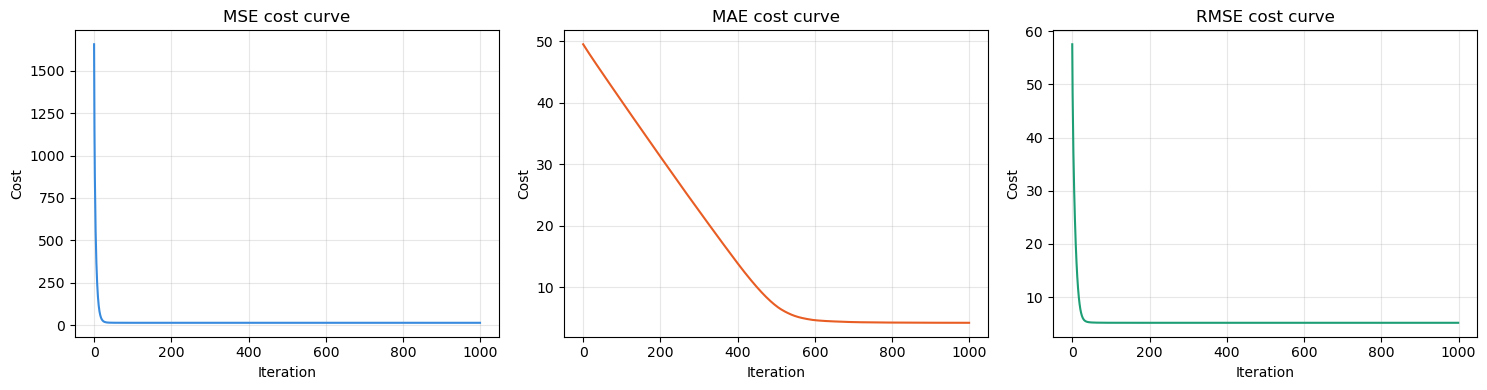


{'Cost fn':<8} {'Test MSE':>12} {'Test R²':>10}
----------------------------------
MSE           24.1441     0.9693
MAE           24.1952     0.9692
RMSE          24.1441     0.9693

Plotting gradient descent path for MSE model...


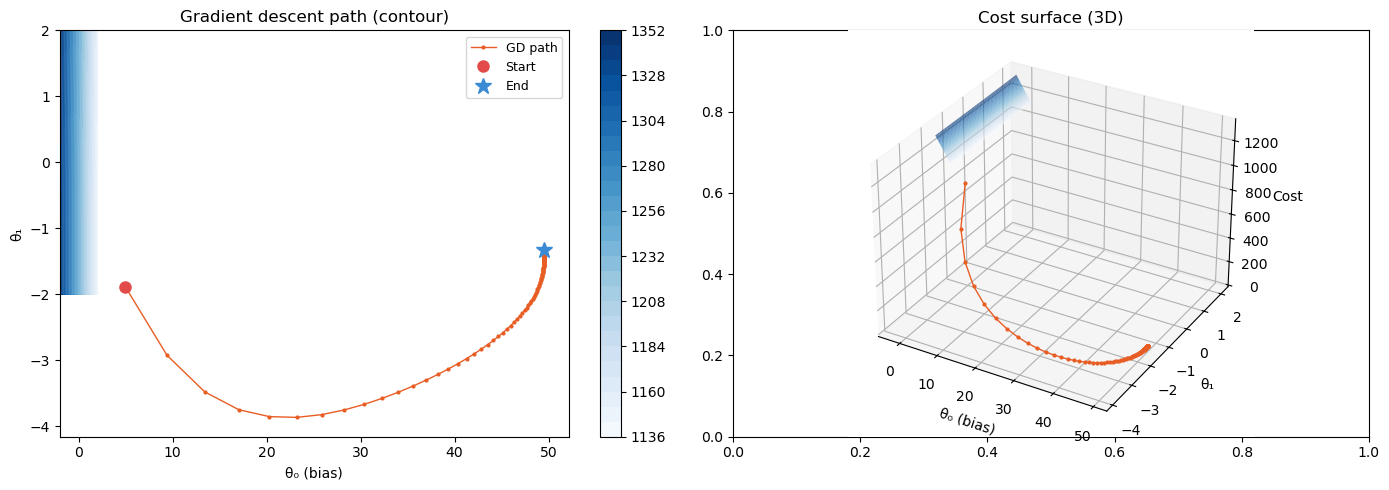

In [6]:
# ── Compare MSE vs MAE vs RMSE ──────────────────────────────────────────────

results = {}
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, cf in enumerate(['mse', 'mae', 'rmse']):
    mdl = LinearRegression(learning_rate=0.1, num_iterations=1000, cost_function=cf)
    hist = mdl.fit(X_train_scaled, y_train, verbose=False)

    test_mse = mdl.score(X_test_scaled, y_test)   # always report MSE for comparison
    preds    = mdl.predict(X_test_scaled)
    r2       = 1 - np.sum((y_test-preds)**2) / np.sum((y_test-y_test.mean())**2)
    results[cf] = {'model': mdl, 'test_mse': test_mse, 'r2': r2}

    axes[idx].plot(hist, linewidth=1.5, color=['#378ADD','#E85D24','#1D9E75'][idx])
    axes[idx].set_title(f'{cf.upper()} cost curve')
    axes[idx].set_xlabel('Iteration'); axes[idx].set_ylabel('Cost')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print("\n{'Cost fn':<8} {'Test MSE':>12} {'Test R²':>10}")
print("-"*34)
for cf, r in results.items():
    print(f"{cf.upper():<8} {r['test_mse']:>12.4f} {r['r2']:>10.4f}")

# Gradient descent path (using best model)
print("\nPlotting gradient descent path for MSE model...")
model_mse.plot_gradient_descent_path(
    X_train_scaled, y_train,
    theta0_range=(-2, 2), theta1_range=(-2, 2), resolution=40
)
#R² close to 1 = good model

### Part B: Regularized Linear Regression Using Scikit-learn

Now, you'll use the [scikit-learn](https://scikit-learn.org/stable/index.html) to implement [Linear Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html), [Ridge](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html#sklearn.linear_model.Ridge), [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html#sklearn.linear_model.Lasso), [Elastic Net](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html#sklearn.linear_model.ElasticNet) and apply them to the human-zombie dataset.

Try out different values of regularization coefficient (known as `alpha` in `sklearn`) and use the [Mean Squared Error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html) to report loss with each regression.

Finally, plot the regularization coefficients alpha (x-axis) with learned parameters $\theta$ (y-axis) for Ridge and Lasso. Please read [this blog](https://scienceloft.com/technical/understanding-lasso-and-ridge-regression/) to get better understanding of the desired plots.


#### Importing Libraries

You have to use scikit-learn for this task

In [7]:
# Part B imports
from sklearn.linear_model import LinearRegression as SKLearnLR, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error


#### Linear Regression (using `sklearn`)

Use the [Mean Squared Error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html) to find loss and print it.

In [8]:
# ── sklearn Vanilla Linear Regression ───────────────────────────────────────
lr_sk = SKLearnLR()
lr_sk.fit(X_train_scaled, y_train)

preds_train = lr_sk.predict(X_train_scaled)
preds_test  = lr_sk.predict(X_test_scaled)

train_mse = mean_squared_error(y_train, preds_train)
test_mse  = mean_squared_error(y_test,  preds_test)
r2        = lr_sk.score(X_test_scaled, y_test)

print("sklearn LinearRegression")
print(f"  Train MSE : {train_mse:.4f}")
print(f"  Test  MSE : {test_mse:.4f}")
print(f"  Test  R²  : {r2:.4f}")
print(f"  Intercept (bias b): {lr_sk.intercept_:.4f}")
print(f"  Coefficients: {np.round(lr_sk.coef_, 4)}")


sklearn LinearRegression
  Train MSE : 26.6279
  Test  MSE : 24.1441
  Test  R²  : 0.9693
  Intercept (bias b): 49.5365
  Coefficients: [-1.3349 -0.3092  2.5121  7.9333 -9.8366 -8.9532]


#### Ridge

Use the [Mean Squared Error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html) to find loss and print it. Also plot the regularization coefficients alpha (x-axis) with learned parameters $\theta$  (y-axis) for Ridge.

  alpha=  0.001  |  Test MSE = 24.1441
  alpha=   0.01  |  Test MSE = 24.1440
  alpha=    0.1  |  Test MSE = 24.1434
  alpha=      1  |  Test MSE = 24.1374
  alpha=     10  |  Test MSE = 24.1094
  alpha=    100  |  Test MSE = 25.6182
  alpha=   1000  |  Test MSE = 73.8757


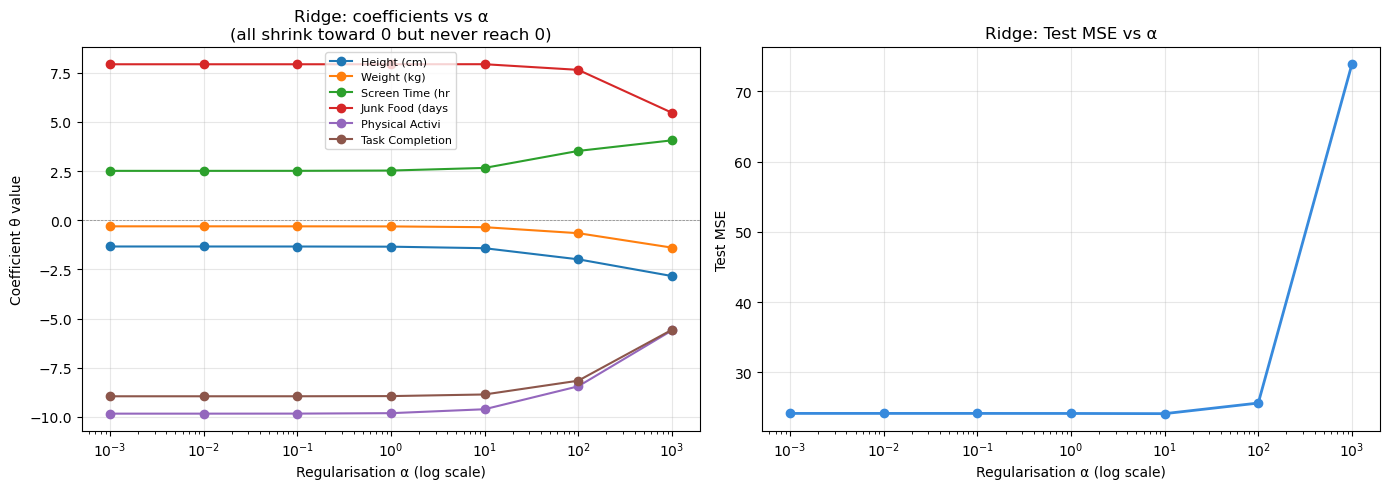

In [9]:
# ── Ridge Regression ────────────────────────────────────────────────────────
# Ridge adds L2 penalty: J(θ) = MSE + α * Σ θⱼ²
# This shrinks large coefficients, preventing overfitting.

alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
ridge_coefs   = []
ridge_mse     = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train)
    preds = ridge.predict(X_test_scaled)
    ridge_coefs.append(ridge.coef_.copy())
    ridge_mse.append(mean_squared_error(y_test, preds))
    print(f"  alpha={a:>7}  |  Test MSE = {ridge_mse[-1]:.4f}")

ridge_coefs = np.array(ridge_coefs)   # (len(alphas), n_features)

# Plot: alpha vs learned parameters
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for j, col in enumerate(feature_cols):
    axes[0].plot(alphas, ridge_coefs[:, j], marker='o', label=col[:15])
axes[0].set_xscale('log')
axes[0].set_xlabel('Regularisation α (log scale)')
axes[0].set_ylabel('Coefficient θ value')
axes[0].set_title('Ridge: coefficients vs α\n(all shrink toward 0 but never reach 0)')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[0].axhline(0, color='gray', linewidth=0.5, linestyle='--')

axes[1].plot(alphas, ridge_mse, 'o-', color='#378ADD', linewidth=2)
axes[1].set_xscale('log')
axes[1].set_xlabel('Regularisation α (log scale)')
axes[1].set_ylabel('Test MSE')
axes[1].set_title('Ridge: Test MSE vs α')
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


#### Lasso

Use the [Mean Squared Error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html) to find loss and print it. Also plot the regularization coefficients alpha (x-axis) with learned parameters $\theta$  (y-axis) for Lasso.

  alpha= 0.001  |  Test MSE = 24.1441  |  zero coeffs = 0/6
  alpha=  0.01  |  Test MSE = 24.1469  |  zero coeffs = 0/6
  alpha=   0.1  |  Test MSE = 24.1950  |  zero coeffs = 0/6
  alpha=   0.5  |  Test MSE = 24.6974  |  zero coeffs = 1/6
  alpha=     1  |  Test MSE = 25.6681  |  zero coeffs = 1/6
  alpha=     5  |  Test MSE = 52.0245  |  zero coeffs = 2/6
  alpha=    10  |  Test MSE = 125.4133  |  zero coeffs = 3/6


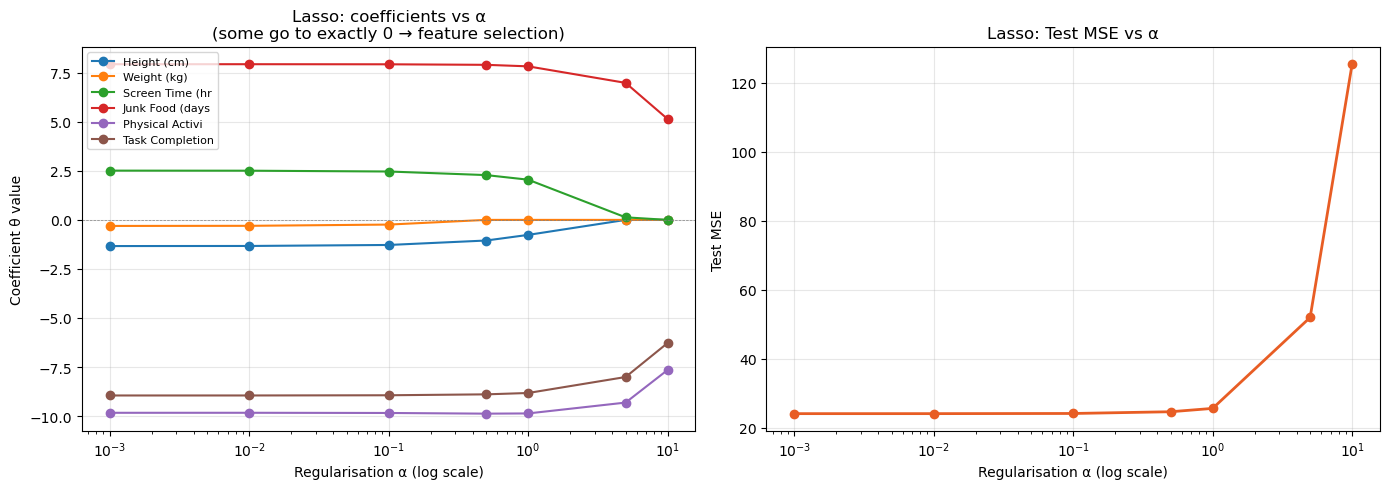


Coefficients comparison at alpha=0.1:
Feature                             Ridge      Lasso
----------------------------------------------------
Height (cm)                       -1.3358    -1.2784
Weight (kg)                       -0.3096    -0.2387
Screen Time (hrs)                  2.5136     2.4669
Junk Food (days/week)              7.9335     7.9326
Physical Activity (hrs/week)      -9.8342    -9.8435
Task Completion (scale)           -8.9523    -8.9410


In [10]:
# ── Lasso Regression ────────────────────────────────────────────────────────
# Lasso adds L1 penalty: J(θ) = MSE + α * Σ |θⱼ|
# KEY difference from Ridge: Lasso drives some coefficients to EXACTLY zero
# → automatic feature selection!

alphas = [0.001, 0.01, 0.1, 0.5, 1, 5, 10]
lasso_coefs = []
lasso_mse   = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    preds = lasso.predict(X_test_scaled)
    lasso_coefs.append(lasso.coef_.copy())
    lasso_mse.append(mean_squared_error(y_test, preds))
    n_zero = np.sum(np.abs(lasso.coef_) < 1e-4)
    print(f"  alpha={a:>6}  |  Test MSE = {lasso_mse[-1]:.4f}  |  zero coeffs = {n_zero}/{len(feature_cols)}")

lasso_coefs = np.array(lasso_coefs)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for j, col in enumerate(feature_cols):
    axes[0].plot(alphas, lasso_coefs[:, j], marker='o', label=col[:15])
axes[0].set_xscale('log')
axes[0].set_xlabel('Regularisation α (log scale)')
axes[0].set_ylabel('Coefficient θ value')
axes[0].set_title('Lasso: coefficients vs α\n(some go to exactly 0 → feature selection)')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[0].axhline(0, color='gray', linewidth=0.5, linestyle='--')

axes[1].plot(alphas, lasso_mse, 'o-', color='#E85D24', linewidth=2)
axes[1].set_xscale('log')
axes[1].set_xlabel('Regularisation α (log scale)')
axes[1].set_ylabel('Test MSE')
axes[1].set_title('Lasso: Test MSE vs α')
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Side-by-side Ridge vs Lasso coeff comparison at alpha=0.1
print("\nCoefficients comparison at alpha=0.1:")
print(f"{'Feature':<30} {'Ridge':>10} {'Lasso':>10}")
print("-"*52)
ridge_01 = Ridge(alpha=0.1).fit(X_train_scaled, y_train)
lasso_01 = Lasso(alpha=0.1).fit(X_train_scaled, y_train)
for col, rc, lc in zip(feature_cols, ridge_01.coef_, lasso_01.coef_):
    print(f"{col:<30} {rc:>10.4f} {lc:>10.4f}")


#### Elastic Net

Use the [Mean Squared Error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html) to find loss and print it.

alpha    l1_ratio         Test MSE       R²
--------------------------------------------
0.001    0.1               24.1392   0.9693
0.001    0.5               24.1412   0.9693
0.001    0.9               24.1435   0.9693
0.01     0.1               24.1123   0.9693
0.01     0.5               24.1229   0.9693
0.01     0.9               24.1412   0.9693
0.1      0.1               24.9238   0.9683
0.1      0.5               24.3576   0.9690
0.1      0.9               24.1545   0.9693
0.5      0.1               36.1542   0.9540
0.5      0.5               29.5514   0.9624
0.5      0.9               24.8497   0.9684
1        0.1               56.6847   0.9278
1        0.5               40.3754   0.9486
1        0.9               26.9732   0.9657
10       0.1              402.1639   0.4881
10       0.5              340.9167   0.5661
10       0.9              199.3494   0.7463

Best Elastic Net → alpha=0.01, l1_ratio=0.1, Test MSE=24.1123


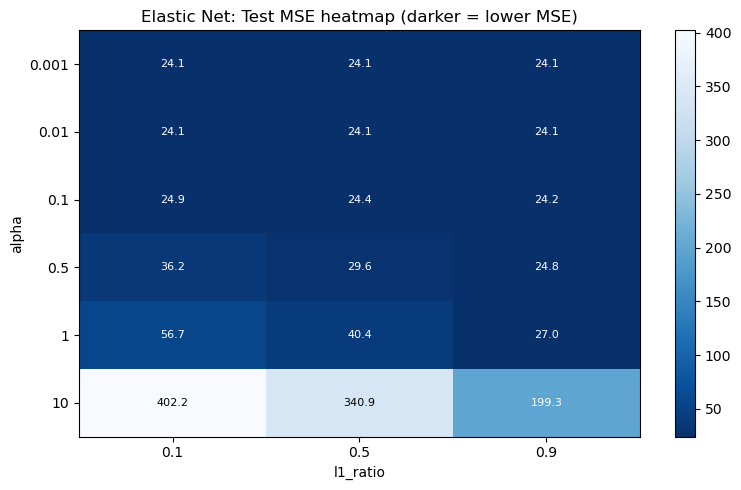


FINAL MODEL COMPARISON  (Test MSE, lower = better)
  LinearRegression          MSE = 24.1441   R² = 0.9693
  Ridge (α=0.1)             MSE = 24.1434   R² = 0.9693
  Lasso (α=0.1)             MSE = 24.1950   R² = 0.9692
  ElasticNet (best)         MSE = 24.1123   R² = 0.9693


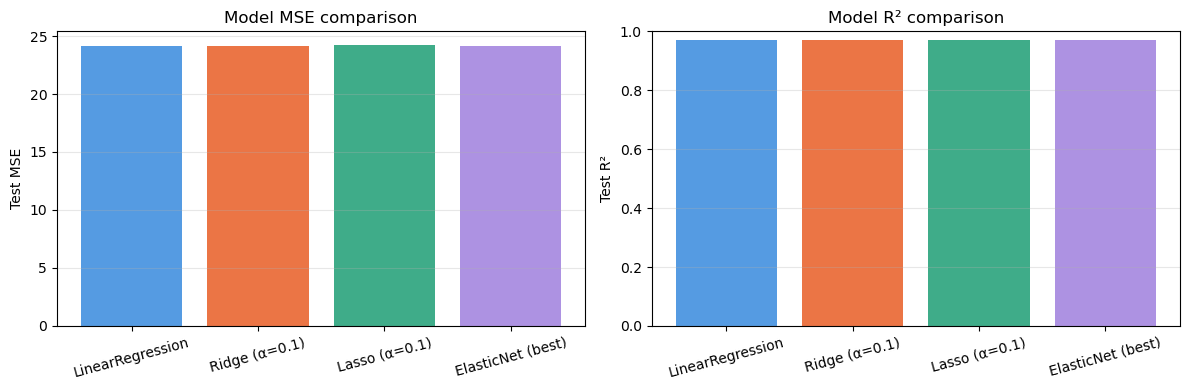

In [11]:
# ── Elastic Net ─────────────────────────────────────────────────────────────
# Elastic Net = L1 + L2 penalty (best of both Ridge and Lasso)
# J(θ) = MSE + α*l1_ratio*Σ|θⱼ| + α*(1-l1_ratio)/2*Σθⱼ²

alphas   = [0.001, 0.01, 0.1, 0.5, 1, 10]
l1_ratios = [0.1, 0.5, 0.9]

print(f"{'alpha':<8} {'l1_ratio':<12} {'Test MSE':>12} {'R²':>8}")
print("-"*44)

best_mse, best_params, best_model = np.inf, {}, None
results_en = []

for a in alphas:
    for l1 in l1_ratios:
        en    = ElasticNet(alpha=a, l1_ratio=l1, max_iter=10000)
        en.fit(X_train_scaled, y_train)
        preds = en.predict(X_test_scaled)
        mse   = mean_squared_error(y_test, preds)
        r2    = en.score(X_test_scaled, y_test)
        results_en.append((a, l1, mse))
        print(f"{a:<8} {l1:<12} {mse:>12.4f} {r2:>8.4f}")
        if mse < best_mse:
            best_mse, best_params, best_model = mse, {'alpha': a, 'l1_ratio': l1}, en

print(f"\nBest Elastic Net → alpha={best_params['alpha']}, "
      f"l1_ratio={best_params['l1_ratio']}, Test MSE={best_mse:.4f}")

# Heatmap of MSE over alpha x l1_ratio
import matplotlib.pyplot as plt
mse_grid = np.array([r[2] for r in results_en]).reshape(len(alphas), len(l1_ratios))

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(mse_grid, aspect='auto', cmap='Blues_r')
ax.set_xticks(range(len(l1_ratios))); ax.set_xticklabels(l1_ratios)
ax.set_yticks(range(len(alphas)));    ax.set_yticklabels(alphas)
ax.set_xlabel('l1_ratio'); ax.set_ylabel('alpha')
ax.set_title('Elastic Net: Test MSE heatmap (darker = lower MSE)')
plt.colorbar(im, ax=ax)
for i in range(len(alphas)):
    for j in range(len(l1_ratios)):
        ax.text(j, i, f'{mse_grid[i,j]:.1f}', ha='center', va='center',
                color='white' if mse_grid[i,j] < mse_grid.max()*0.6 else 'black', fontsize=8)
plt.tight_layout(); plt.show()

# ── Final comparison: all 4 models ──────────────────────────────────────────
print("\n" + "="*55)
print("FINAL MODEL COMPARISON  (Test MSE, lower = better)")
print("="*55)

models_final = {
    'LinearRegression' : SKLearnLR(),
    'Ridge (α=0.1)'    : Ridge(alpha=0.1),
    'Lasso (α=0.1)'    : Lasso(alpha=0.1, max_iter=10000),
    f'ElasticNet (best)': best_model
}

names, mses, r2s = [], [], []
for name, mdl in models_final.items():
    if name != f'ElasticNet (best)':
        mdl.fit(X_train_scaled, y_train)
    p   = mdl.predict(X_test_scaled)
    mse = mean_squared_error(y_test, p)
    r2  = mdl.score(X_test_scaled, y_test)
    names.append(name); mses.append(mse); r2s.append(r2)
    print(f"  {name:<25} MSE = {mse:.4f}   R² = {r2:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#378ADD', '#E85D24', '#1D9E75', '#9F7FDD']
axes[0].bar(names, mses, color=colors, alpha=0.85)
axes[0].set_ylabel('Test MSE'); axes[0].set_title('Model MSE comparison')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(names, r2s, color=colors, alpha=0.85)
axes[1].set_ylabel('Test R²'); axes[1].set_title('Model R² comparison')
axes[1].tick_params(axis='x', rotation=15)
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout(); plt.show()
